In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from random import shuffle

In [2]:
from skimage.transform import matrix_transform

In [3]:
import acanalysis.acalignment.match_keypoints as mk
from acanalysis.acalignment.keypoints import write_keypoints_to_file,read_keypoints
from acanalysis.acalignment.transforms import ransac
from utils import get_section_label, get_roi_label

In [4]:
# Alignment json describing the set of segmented ROI's (SROI's) from each
# section image to be jointly aligned, the image (zarr) data cutout regions
# underlying the segmentation, and file path information to locate
# the zarr datasets and skeletons
with open("align_S32_S33_roi1_mip0.json") as f:
    alignjs = json.load(f)
outpath = Path(alignjs["output_path"])
global_reg_matrix_path = Path("J:/Users/kevin/alignment_files/M0_roi2.npy")
#global_reg_matrix_path = Path("M0_S40_S39_roi1.npy")

In [5]:
# combine keypoints from SROI's in each section
combined_kps = []
for s in alignjs["sections"]:
    tiles = s["tiles"]
    offsets = s["position_offsets"]
    rois = [outpath / Path(get_roi_label(s,i) + "_keypoints.json") for i,tid in enumerate(tiles)]
    kps = mk.combine_tile_keypoints(rois,offsets,shuffle=False)
    print(len(kps))
    combined_kps.append(kps)

2402
4349


In [6]:
# function to filter out keypoints with vectors parallel to horizontal (surface)
def filter_angles(keypts,maxangle):
    vecs = [kp.vector for kp in keypts]
    angles = np.arccos(np.array([np.abs(np.dot(np.array([1,0,0]),v)) for v in vecs]))*180/np.pi
    return [keypts[i] for i in np.nonzero(angles<maxangle)[0]]

def filter_sub_roi(keypts,coords,tform=None,axes=None):
    coord_axes = [a for a in range(len(coords)) if coords[a]]
    if tform is None:
        locs = np.array([k.location for k in keypts])
    else:
        locs,vecs = transform_keypoints(keypts,tform,axes)
    return [kp for i,kp in enumerate(keypts) if all([(locs[i,a]>=coords[a][0])and(locs[i,a]<coords[a][1]) for a in coord_axes])]

def transform_keypoints(keypts,rigidM,axes=None):
    locs = np.array([k.location for k in keypts])
    vecs = np.array([k.vector for k in keypts])
    rotM = np.eye(3)
    rotM[:2,:2] = rigidM[:2,:2]
    locs[:,axes] = matrix_transform(locs[:,axes],matrix=rigidM)
    vecs[:,axes] = matrix_transform(vecs[:,axes],matrix=rotM)
    return locs,vecs

In [7]:
# coarse initialization from global registration
M0 = np.load(global_reg_matrix_path)

In [14]:
# filter keypoints by angle of impact
filter_params = [
    {
    "angle":75,
    "coords":None,#[[],[1000,3000],[0,6000]], #None
    "tform":None
    },
    {
    "angle":75,
    "coords":None,#[[],[1000,3000],[0,6000]], #None
    "tform":M0
    }
]
filtered_kps = []
for kps,params in zip(combined_kps,filter_params):
    kps1 = kps
    if not params["angle"] is None:
        kps1 = filter_angles(kps1,params["angle"])
    if not params["coords"] is None:
        kps1 = filter_sub_roi(kps1,params["coords"],params["tform"],[1,2])
    filtered_kps.append(kps1)
    print(len(kps1))

1324
2471


In [15]:
# parameter search with loose solve to refine initial estimate
# by number of consensus inliers over rotation angle and translation
def match_ransac_for_theta(kps0,kps1,theta,trans,M0=None):
    minmatches = 5
    if M0 is None:
        M0 = np.eye(3)
    M = np.array([[np.cos(theta), np.sin(theta), trans[0]],
                  [-np.sin(theta), np.cos(theta), trans[1]],
                  [0,0,1]]) @ M0
    match0,match1,distances = mk.match_keypoint_sets(kps0,kps1,axes=[1,2],tforms0=None,tforms1=[M],rball=100,mincosine=0.6)
    if len(match0) >= minmatches:
        dst_pts = np.array([kp.location[1:] for kp in match0])
        src_pts = np.array([kp.location[1:] for kp in match1])
        best_model,best_inliers = ransac([src_pts,dst_pts],epsilon=50,iterations=1000,minNumInliers=6,showProgress=False)
        return best_model,best_inliers
    else:
        return None,None

0 out of 31
89
1 out of 31
125
2 out of 31
139
3 out of 31
133
4 out of 31
151
5 out of 31
160
6 out of 31
196
7 out of 31
202
8 out of 31
206
9 out of 31
235
10 out of 31
237
11 out of 31
281
12 out of 31
280
13 out of 31
290
14 out of 31
296
15 out of 31
320
16 out of 31
307
17 out of 31
288
18 out of 31
281
19 out of 31
294
20 out of 31
296
21 out of 31
269
22 out of 31
242
23 out of 31
241
24 out of 31
219
25 out of 31
197
26 out of 31
184
27 out of 31
176
28 out of 31
174
29 out of 31
152
30 out of 31
150
15
[[0.9965079962294394, 0.08349738589194089, -189.12943356091853], [-0.08349738589194089, 0.9965079962294394, 295.63735345904547]]


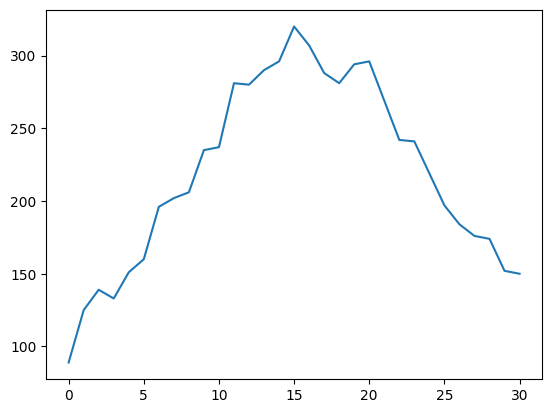

In [20]:
# set up and run parameter search
theta0 = 0*np.pi/180
trans0 = np.array([0,0])
dt = np.arange(-30,30.5,2)*np.pi/180
#dx = np.arange(-300,325,50)
dx = np.array([0])
numinliers = np.zeros(dt.shape)
models = []
kp0 = filtered_kps[0]
kp1 = filtered_kps[1]
for i,t in enumerate(dt):
    print(str(i) + " out of " + str(dt.shape[0]))
    most_inliers = 0
    best_inliers = None
    for i0,x0 in enumerate(dx):
        for i1,x1 in enumerate(dx):
            trans = trans0 + np.array([x0,x1])
            model,inliers = match_ransac_for_theta(kp0,kp1,t+theta0,trans,M0)
            if not inliers is None:
                if np.sum(inliers) > most_inliers:
                    best_inliers = inliers
                    best_model = model
    if not best_inliers is None:
        print(np.sum(best_inliers))
        numinliers[i] = np.sum(best_inliers)
        models.append(best_model.params.tolist())
    else:
        models.append([])
plt.plot(numinliers)
imax = np.argmax(numinliers)
print(imax)
print(models[imax])

In [21]:
# refined initial estimate of rigid transformation matrix to align sections
rigid_M = np.array(models[imax]+[[0,0,1]])
print(rigid_M)
print(M0)

[[ 9.96507996e-01  8.34973859e-02 -1.89129434e+02]
 [-8.34973859e-02  9.96507996e-01  2.95637353e+02]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]
[[ 9.96682331e-01  8.13899975e-02 -2.04211105e+02]
 [-8.13899975e-02  9.96682331e-01  2.54925568e+02]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]


In [22]:
print(np.arcsin(rigid_M[0,1])*180/np.pi)

4.7896242395897435


In [23]:
M0 = rigid_M

In [24]:
# tight matching for correspondence generation
# match keypoints between sections based on lying within "aligned" neighborhood (ball query)
# and highest alignment of vectors (cosine)
match0,match1,distances = mk.match_keypoint_sets(kp0,kp1,axes=[1,2],tforms0=None,tforms1=[rigid_M],rball=100,mincosine=0.8)
print(len(match0))

940


In [25]:
# ignore z (height) coordinate for 2D alignment of locations
# projects endpoints onto a flat plane
pts0_dst = np.array([kp.location[1:] for kp in match0])
pts1_src = np.array([kp.location[1:] for kp in match1])

In [26]:
# ransac for rigid transformation and correspondences
best_model,best_inliers = ransac([pts1_src,pts0_dst],epsilon=50,iterations=10000,minNumInliers=6,showProgress=True)

0 : 243
1 : 260
10 : 266
154 : 268
177 : 272
657 : 273


In [27]:
# rigid transformation should be close to initial estimate
best_model.params.tolist()

[[0.9954869535884994, 0.0948984996461459, -199.97471167324818],
 [-0.09489849964614601, 0.9954869535884991, 308.5432713971031]]

In [29]:
# subselect better correspondences with smaller residuals
filtered_inliers = np.linalg.norm(best_model.tform(pts1_src) - pts0_dst,axis=1) <= 30
inliers0 = [match0[i] for i in np.nonzero(filtered_inliers)[0]]
inliers1 = [match1[i] for i in np.nonzero(filtered_inliers)[0]]
print(len(inliers0))

86


In [30]:
# function to remove duplicate matches to avoid singular warp matrix
# duplicates removed by minimizing distance
from collections import defaultdict
def remove_duplicate_matches(kplist0,kplist1):
    kpset0 = []
    kpset1 = []
    D = defaultdict(list)
    for i,kp in enumerate(kplist0):
        D[kp.name].append(i)
    for name in D:
        if len(D[name]) == 1:
            i = D[name][0]
        else:
            i = D[name][np.argmin(np.linalg.norm(np.array([kplist0[ii].location - kplist1[ii].location for ii in D[name]]),axis=1))]
        kpset0.append(kplist0[i])
        kpset1.append(kplist1[i])
    return kpset0,kpset1

In [31]:
# remove duplicates from both sets
inliers0,inliers1 = remove_duplicate_matches(inliers0,inliers1)
inliers1,inliers0 = remove_duplicate_matches(inliers1,inliers0)
print(len(inliers0))

79


In [32]:
# save output files
inliers = [inliers0,inliers1]
warppts = [np.array([kp.location[1:] for kp in inliers0]),best_model.tform(np.array([kp.location[1:] for kp in inliers1]))]
modelfile = outpath / Path("model.npy")
np.save(modelfile,best_model.M)
for i,s in enumerate(alignjs["sections"]):
    outputpath = outpath / Path(get_section_label(s) + "_inliers.json")
    write_keypoints_to_file(inliers[i],outputpath)
    output2path = outpath / Path(get_section_label(s) + "_filtered.json")
    write_keypoints_to_file(filtered_kps[i],output2path)
    npypath = outpath / Path(get_section_label(s) + "_warp_pts.npy")
    np.save(npypath,warppts[i])